# Test: `earthkit.geo.regrid` ICON -> NWCSAF grid

Single-file smoke test of the pasted approach. Paths from `ICON_to_NWCSAF.ipynb`
(exp 801 first guess, 2025-10-06 11 UTC).

Deviations from the pasted script, each needed to make it run:

1. `import eccodes` first (repo convention, otherwise `eckit` aborts with
   *"Factory(area) has already a builder for bounding_box"*).
2. The NWCSAF file names its coordinates `longitude`/`latitude`, and they are
   **2-D** (341, 482). A flat `np.diff` on `latitude` therefore gives `dlat = 0.0`;
   the spacing has to be taken along the right axis.
3. `ekd.from_source(...)` returns a `GribData`, which `ekg.regrid` rejects
   (*"Unsupported type"*). `.to_fieldlist()` is required.

**Result: it runs and produces a `regular_ll` field, but the output grid is
322 x 477, not the NWCSAF 341 x 482** — MIR snaps the requested `area` to its
own grid alignment (north moves 51.087 -> 50.574). See the last cell.

In [1]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

import eccodes  # must come before earthkit.data
import numpy as np
import xarray as xr
import earthkit.data as ekd
import earthkit.geo as ekg

NWCSAF_FILE = "/scratch/mch/jdelbeke/nwcsaf/MSG_nwcsaf_cosmo1eqc3km_202510061100.nc"
ICON_FILE = "/store_new/mch/msopr/jdelbeke/ICON_TST/801/FG25/det/lff2025100611"

sat = xr.open_dataset(NWCSAF_FILE)

# 2-D coordinate arrays -> take the 1-D axes
lat = sat["latitude"].values[:, 0]
lon = sat["longitude"].values[0, :]

dlat = float(np.median(np.abs(np.diff(lat))))
dlon = float(np.median(np.abs(np.diff(lon))))

target_grid = {
    "grid": [dlon, dlat],
    "area": [
        float(lat.max()),   # north
        float(lon.min()),   # west
        float(lat.min()),   # south
        float(lon.max()),   # east
    ],
}
print("NWCSAF grid :", sat["latitude"].shape)
print("target_grid :", target_grid)

NWCSAF grid : (341, 482)
target_grid : {'grid': [0.038796680497914515, 0.026979472140759242], 'area': [51.0865102639291, -1.0806016597484531, 41.9134897360709, 17.580601659748453]}


In [2]:
# .to_fieldlist() is required -- regrid() rejects the raw GribData source.
icon = ekd.from_source("file", ICON_FILE).to_fieldlist()
icon = icon.sel({"parameter.variable": "CLCT"})
print("input fields:", len(icon))

# First call builds the MIR weight matrix (a few minutes, ~1.15e6 ICON cells)
# and caches it under /tmp/cache/mir/weights/...; later calls reuse it.
icon_on_nwcsaf = ekg.regrid(
    icon,
    out_grid=target_grid,
    interpolation="linear",
)

print(type(icon_on_nwcsaf), len(icon_on_nwcsaf))

input fields: 1


<class 'earthkit.data.indexing.simple.SimpleFieldList'> 1


In [3]:
# Does the output grid actually match NWCSAF?
f = icon_on_nwcsaf[0]
arr = f.to_numpy()

print("gridType      :", f.metadata("gridType"))
print("out shape     :", arr.shape, " values", np.nanmin(arr), "..", np.nanmax(arr))
print("NWCSAF shape  :", sat["latitude"].shape)
print()
for k in ("latitudeOfFirstGridPointInDegrees", "longitudeOfFirstGridPointInDegrees",
          "latitudeOfLastGridPointInDegrees", "longitudeOfLastGridPointInDegrees",
          "iDirectionIncrementInDegrees", "jDirectionIncrementInDegrees"):
    print(f"{k:40s} {f.metadata(k)}")
print()
print("NWCSAF  N/W/S/E:", lat.max(), lon.min(), lat.min(), lon.max())
print("MATCH:", arr.shape == sat["latitude"].shape)

gridType      : regular_ll
out shape     : (322, 477)  values 0.0 .. 100.0
NWCSAF shape  : (341, 482)

latitudeOfFirstGridPointInDegrees        50.573901
longitudeOfFirstGridPointInDegrees       359.113381
latitudeOfLastGridPointInDegrees         41.91349
longitudeOfLastGridPointInDegrees        17.580602
iDirectionIncrementInDegrees             0.038797
jDirectionIncrementInDegrees             0.026979

NWCSAF  N/W/S/E: 51.0865102639291 -1.0806016597484531 41.9134897360709 17.580601659748453
MATCH: False


## Plot: one source field, three grids

All three panels show the **same ICON CLCT field**, so any difference between them
is purely the regridding: (a) native triangular mesh, (b) the `ekg.regrid` output,
(c) b brought onto the true NWCSAF grid. Plotted with `earthkit.plots`.

**Step c cannot be done with earthkit/MIR.** Both routes fail:

- `ekg.regrid(b, out_grid=<NWCSAF grid>)` →
  `Assertion failed: w + (ni-1)*lon.inc() == e || ni*lon.inc() == GLOBE`.
  MIR writes its own output GRIB with the increment **rounded to 6 decimals**
  (0.038797 instead of 0.038796680497914515), which leaves the message internally
  inconsistent by 1.5e-4 deg — so MIR refuses to read back the grid it just wrote.
- An `eckit.geo.Grid` built from the NWCSAF axes *is* exactly 341x482, but passing
  it as `out_grid` still snaps to 321x477: MIR ignores the spec's `reference` key
  and aligns to its own global grid.

So c uses `xarray.interp`, i.e. the same bilinear interpolation performed outside
MIR. Since b is already a regular lat/lon grid this is a plain 2-D interpolation,
not an approximation of one.

Two plotting traps worth knowing:

1. **`b.to_xarray()` gives a broken longitude axis.** MIR writes
   `longitudeOfFirstGridPointInDegrees = 359.113` (-0.887 wrapped past 0) and
   `to_xarray()` wraps the *last* element back to the first, so the coordinate reads
   `-0.887, ..., 17.542, -0.887` — non-monotonic, and `pcolormesh` smears every row
   across the panel. The axes are rebuilt from metadata below, using the
   full-precision increment rather than the rounded GRIB one.
2. **Values exactly on the top style level render transparent.** CLCT saturates at
   exactly 100, which counts as "over" and disappears; `extend="max"` fixes it.


c shape: (341, 482) == NWCSAF (341, 482)
NaN fraction: 13.4% of the full grid, 0.0% inside the plot domain


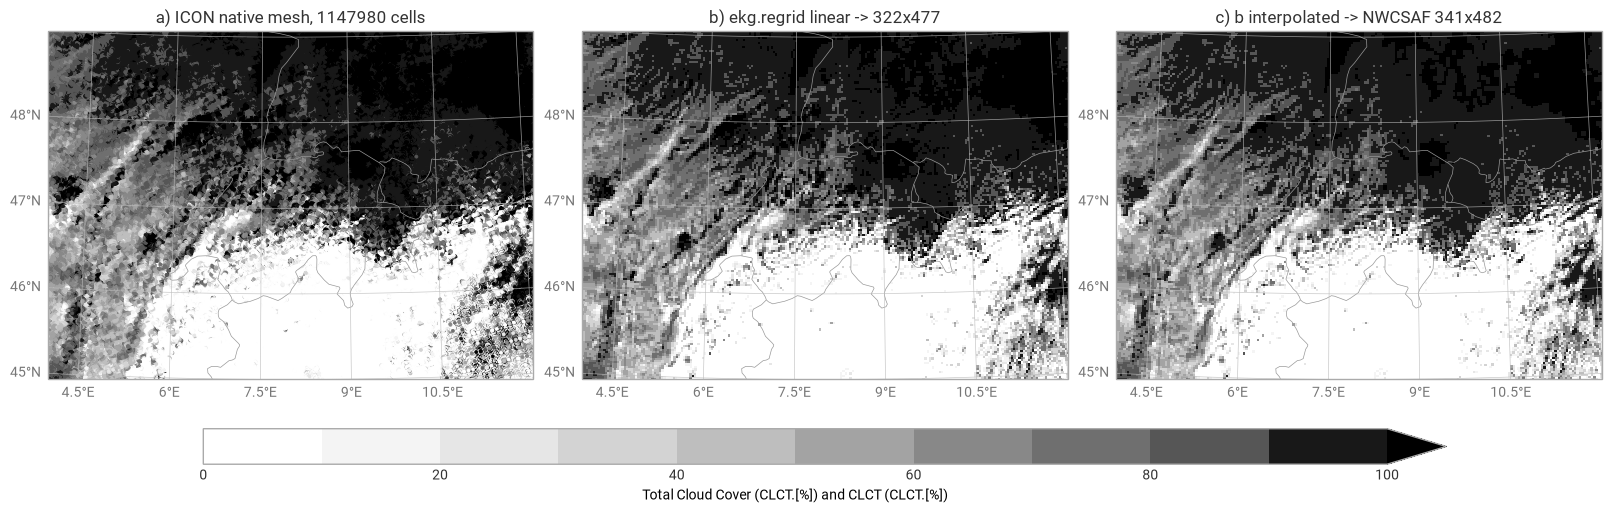

In [4]:
import earthkit.plots as ekp

DOMAIN = [4, 12, 45, 49]          # lon W, lon E, lat S, lat N

# --- b: rebuild the output axes from GRIB metadata ---------------------------
# to_xarray()'s longitude wraps at the end, and the GRIB-encoded increment is
# rounded to 6 dp, so use the full-precision dlon/dlat we asked for instead.
ni, nj = f.metadata("Ni"), f.metadata("Nj")
lon0 = f.metadata("longitudeOfFirstGridPointInDegrees")
lon0 = lon0 - 360 if lon0 > 180 else lon0
olon = lon0 + np.arange(ni) * dlon
olat = f.metadata("latitudeOfFirstGridPointInDegrees") - np.arange(nj) * dlat
assert np.all(np.diff(olon) > 0), "longitude axis must be monotonic"

out_da = xr.DataArray(
    arr,
    coords={"latitude": ("latitude", olat), "longitude": ("longitude", olon)},
    dims=("latitude", "longitude"), name="CLCT",
)

# --- c: b interpolated onto the exact NWCSAF grid ----------------------------
# MIR cannot target this grid (see the notes above), so interpolate with xarray.
# interp() needs ascending coordinates, hence the sortby round-trip.
c_da = (out_da.sortby("latitude")
              .interp(latitude=lat[::-1], longitude=lon, method="linear")
              .sortby("latitude", ascending=False))
c_da.name = "CLCT"

assert c_da.shape == sat["latitude"].shape, "c must be on the NWCSAF grid"
print("c shape:", c_da.shape, "== NWCSAF", sat["latitude"].shape)

# b does not cover the full NWCSAF box (MIR clipped the north/west edges), so
# those target pixels have no source data and come back NaN.
nan_all = float(np.isnan(c_da.values).mean())
inside = c_da.sel(latitude=slice(DOMAIN[3], DOMAIN[2]),
                  longitude=slice(DOMAIN[0], DOMAIN[1]))
print(f"NaN fraction: {nan_all:.1%} of the full grid, "
      f"{float(np.isnan(inside.values).mean()):.1%} inside the plot domain")

# sequential single hue; extend="max" so values sitting exactly on 100 still show
CLCT_STYLE = ekp.Style(colors="Greys", levels=np.arange(0, 101, 10), normalize=True,
                       extend="max", units_label="CLCT [%]")

fig = ekp.Figure(rows=1, columns=3, figsize=(16, 6), domain=DOMAIN)

m = fig.add_map(row=0, column=0)
m.point_cloud(icon[0], style=CLCT_STYLE)
m.coastlines(); m.borders(); m.gridlines()
m.title(f"a) ICON native mesh, {icon[0].to_numpy().size} cells")

m = fig.add_map(row=0, column=1)
m.pcolormesh(out_da, style=CLCT_STYLE)
m.coastlines(); m.borders(); m.gridlines()
m.title(f"b) ekg.regrid linear -> {nj}x{ni}")

m = fig.add_map(row=0, column=2)
m.pcolormesh(c_da, style=CLCT_STYLE)
m.coastlines(); m.borders(); m.gridlines()
m.title(f"c) b interpolated -> NWCSAF {c_da.shape[0]}x{c_da.shape[1]}")

fig.legend()
fig.show()

## Verdict

`ekg.regrid` interpolates the ICON native triangular mesh onto a regular lat/lon
grid correctly, and MIR caches the weight matrix, so the mechanism itself is sound
and cheap to reuse. Panels a and b agree closely.

But **it cannot land on the NWCSAF grid**, for two independent reasons:

1. The NWCSAF grid is regular but not globally aligned — its increments do not
   divide the globe evenly (`360/dlon = 9279.14`) and its corners are not integer
   multiples of the increments. MIR treats `area` as a crop of its own aligned
   global grid, so it clips to 322x477 with the north edge moved by ~0.51 deg.
   Passing a fully specified `eckit.geo.Grid` does not help — MIR ignores the
   spec's `reference` and still snaps.
2. MIR's own GRIB output is not round-trippable: it rounds the increment to 6 dp,
   so re-reading it raises
   `Assertion failed: w + (ni-1)*lon.inc() == e || ni*lon.inc() == GLOBE`.
   A two-step MIR chain is therefore not possible either.

**Practical upshot.** Use `ekg.regrid` only as a first step onto a MIR-friendly
grid, then finish with a non-MIR interpolation onto the NWCSAF coordinates (panel c
does this in two lines of `xarray.interp`). Note that this composes two
interpolations and is nearest/bilinear throughout, so it is *not* conservative —
for the area-weighted comparison the hand-rolled triangle clipping in
`ICON_to_NWCSAF.ipynb` is still the right tool, and it hits the NWCSAF grid exactly
in one step.
